<div style="padding: 20px; background-color: #f8f9fa; border-radius: 10px; border-left: 10px solid #28a745;">
    <h1 style="color: #155724; margin-bottom: 5px;">🌾 AI System for Rice Leaf Disease Classification</h1>
    <p style="font-size: 1.1em; color: #6c757d;">An Intelligent Vision Pipeline for Modern Sustainable Agriculture</p>
</div>

### 🔎 Executive Overview
Rice is a staple crop for over half of the global population, yet it remains highly susceptible to various fungal and bacterial diseases. This system implements a high-performance **Deep Learning** solution designed to identify disease patterns with expert-level precision.

**Core Technologies utilized:**
- **Backend Engine:** Keras 3 with PyTorch (Optimized for NVIDIA GTX 1650 Ti)
- **Architecture:** EfficientNetB0 Transfer Learning
- **Explainability:** Grad-CAM focal visualizations
- **Modularity:** Clean, decoupled source code in the `src/` directory

<h2 style="color: #2c3e50; border-bottom: 2px solid #28a745; padding-bottom: 10px;">1. System Initialization & Hardware Setup</h2>

We start by configuring our environment. On Windows native systems, we explicitly set the **Torch** backend for Keras to bypass TensorFlow's GPU limitations, ensuring our GTX 1650 Ti handles the heavy lifting.

In [15]:
%load_ext autoreload
%autoreload 2

import os
import sys

# Set Keras backend to Torch for GPU acceleration on Windows native
os.environ["KERAS_BACKEND"] = "torch"

# Add src directory to system path for modular imports
sys.path.append(os.path.abspath("../src"))

import torch
import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f"🚀 System Ready | Keras Version: {keras.__version__} | Backend: {keras.backend.backend()}")
if torch.cuda.is_available():
    print(f"✅ Hardware: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ Warning: Hardware acceleration not detected.")

🚀 System Ready | Keras Version: 3.14.0 | Backend: torch
✅ Hardware: NVIDIA GeForce GTX 1650


<h2 style="color: #2c3e50; border-bottom: 2px solid #28a745; padding-bottom: 10px;">2. Data Ingestion & Preprocessing</h2>

A clean model starts with clean data. We load our pre-split rice leaf images and prepare our data augmentation pipeline to improve the model's resilience to lighting and orientation variations.

In [16]:
from data_loader import load_datasets, get_augmentation_layer

TRAIN_PATH = "../data/processed/rice_leaf_split/train"
VAL_PATH = "../data/processed/rice_leaf_split/val"
TEST_PATH = "../data/processed/rice_leaf_split/test"

print("📦 Loading datasets into memory...")
train_ds, val_ds, test_ds = load_datasets(TRAIN_PATH, VAL_PATH, TEST_PATH)

classes = sorted(os.listdir(TRAIN_PATH))
print(f"Detected Classes: {classes}")

📦 Loading datasets into memory...
Found 4150 files belonging to 4 classes.
Found 1185 files belonging to 4 classes.
Found 597 files belonging to 4 classes.
Detected Classes: ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']


C:\Users\jegad\AppData\Local\Temp\ipykernel_7564\830660601.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")


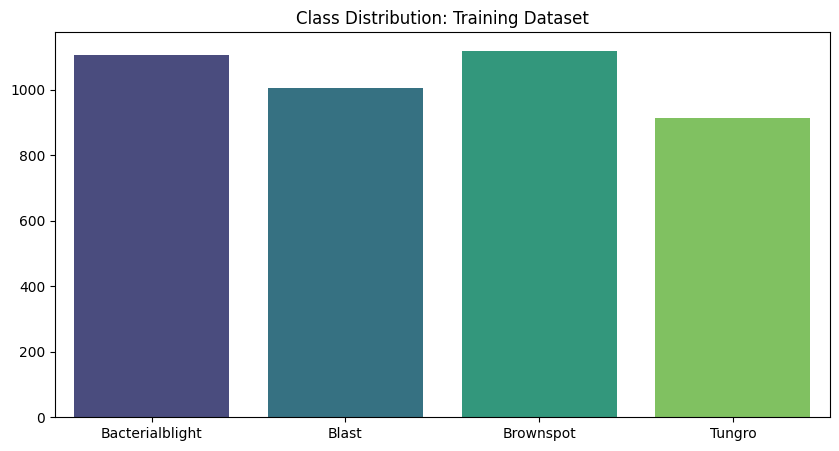

In [17]:
# Visualizing Class Distribution
counts = {cls: len(os.listdir(os.path.join(TRAIN_PATH, cls))) for cls in classes}
plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")
plt.title("Class Distribution: Training Dataset")
plt.savefig("../visualizations/class_distribution.png", bbox_inches='tight')
plt.show()

<h2 style="color: #2c3e50; border-bottom: 2px solid #28a745; padding-bottom: 10px;">3. Neural Architecture Construction</h2>

We utilize **EfficientNetB0**, a scaling-efficient model pre-trained on ImageNet. We decouple the weights from the top layers to allow the model to learn specific agricultural features from our leaf dataset.

In [18]:
from model_builder import build_transfer_model
from keras.applications import EfficientNetB0
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

aug_layer = get_augmentation_layer()
model = build_transfer_model(EfficientNetB0, len(classes), augmentation_layer=aug_layer)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

print("🏗️ Model successfully built. Ready for training.")

🏗️ Model successfully built. Ready for training.


<h2 style="color: #2c3e50; border-bottom: 2px solid #28a745; padding-bottom: 10px;">4. Model Training & Optimization</h2>

We implement dynamic callbacks to prevent overfitting (EarlyStopping) and fine-tune the learning rate (ReduceLROnPlateau) when progress plateaus.

In [20]:
import tensorflow as tf
import gc

gc.collect()

tf.keras.backend.clear_session()

In [ ]:
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.2, patience=2),
    ModelCheckpoint("../models/rice_ai_best.keras", save_best_only=True)
]

print("🔥 Starting training pipeline...")
history = model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=10, 
    callbacks=callbacks,
    verbose=1
)

🔥 Starting training pipeline...
Epoch 1/10
200/519 ━━━━━━━━━━━━━━━━━━━━ 1:49 343ms/step - accuracy: 0.7132 - loss: 0.6652

<h2 style="color: #2c3e50; border-bottom: 2px solid #28a745; padding-bottom: 10px;">5. Rigorous Evaluation</h2>

Performance is measured using blind testing. We generate classification reports and a detailed confusion matrix to see exactly where the model might be confusing similar disease patterns.

In [ ]:
from evaluation import plot_training_history, plot_confusion_matrix

plot_training_history(history, save_path="../visualizations/training_history.png")

In [ ]:
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

plot_confusion_matrix(y_true, y_pred, classes, save_path="../visualizations/confusion_matrix.png")

<h2 style="color: #2c3e50; border-bottom: 2px solid #28a745; padding-bottom: 10px;">6. Visual Explainability (Grad-CAM)</h2>

Trust is critical in agricultural diagnostics. Grad-CAM highlights the specific pixels in the leaf image that led the model to its conclusion, allowing researchers to verify focal points of disease.

In [ ]:
import cv2
import matplotlib.pyplot as plt
from interpretability import make_gradcam_heatmap

print("🔍 Generating AI focal visualizations...")
it = iter(test_ds)
sample_images, sample_labels = next(it)
img_array = sample_images[0:1]

# Generate heatmap using modular src/interpretability.py
heatmap = make_gradcam_heatmap(img_array, model)

# Overlay Rendering
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
img_display = img_array[0].numpy().astype("uint8") if hasattr(img_array[0], 'numpy') else img_array[0]
plt.imshow(img_display)
plt.title("Original Sample")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_display)
plt.imshow(cv2.resize(heatmap, (img_display.shape[1], img_display.shape[0])), cmap='jet', alpha=0.4)
plt.title("AI Attention (Grad-CAM)")
plt.axis("off")
plt.show()

<h2 style="color: #2c3e50; border-bottom: 2px solid #28a745; padding-bottom: 10px;">7. Model Export</h2>

The finalized model is saved for production deployment.

In [ ]:
model.save("../models/ai_system_rice_leaf_final.keras")
print("✨ AI System Deployment Ready.")